In [1]:
import pandas as pd

train_path = r"D:\Python project\PROJECT\data\splits\train.csv"

train_df = pd.read_csv(train_path)

print(train_df.shape)

(1764413, 53)


In [2]:
normal_train = train_df[
    train_df["Attack Type"] == "Normal Traffic"
].copy()

X_normal_train = normal_train.drop(
    columns=["Attack Type"]
)

print("Normal rows:", len(normal_train))
print("Features:", X_normal_train.shape)

Normal rows: 1466427
Features: (1466427, 52)


In [3]:
import numpy as np

print("Data types:")
print(X_normal_train.dtypes.value_counts())

print("NaN:", X_normal_train.isna().sum().sum())

numeric_values = X_normal_train.select_dtypes(include="number")
print("Inf:", np.isinf(numeric_values).sum().sum())

print("Constant columns:")
print([
    col for col in X_normal_train.columns
    if X_normal_train[col].nunique() <= 1
])

Data types:
int64      32
float64    20
Name: count, dtype: int64
NaN: 0
Inf: 0
Constant columns:
[]


In [4]:
from sklearn.preprocessing import StandardScaler 
import numpy as np 

sample = X_normal_train.sample(
    n = 10000, 
    random_state= 42
)
scalar_test = StandardScaler() 
X_scaled_test= scalar_test.fit_transform(sample)

In [5]:
print("Scaled shape:", X_scaled_test.shape)
print("Mean:", np.mean(X_scaled_test))
print("Std:", np.std(X_scaled_test))
print("Finite:", np.isfinite(X_scaled_test).all())

Scaled shape: (10000, 52)
Mean: -2.6986959675503804e-19
Std: 1.0
Finite: True


Scaled shape: (10000, 52)
Mean: gần 0
Std: gần 1
Finite: True

In [6]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

scaler.fit(X_normal_train) 
print("Scaler fitted:", True)
print("Features:", len(scaler.mean_))


Scaler fitted: True
Features: 52


In [7]:
sample_scaled = scaler.transform(
    X_normal_train.sample(n=10_000, random_state=42)
)

print("Shape:", sample_scaled.shape)
print("Finite:", np.isfinite(sample_scaled).all())

Shape: (10000, 52)
Finite: True


In [8]:
import numpy as np

ae_sample_raw = X_normal_train.sample(
    n=min(100_000, len(X_normal_train)),
    random_state=42
)

ae_sample = scaler.transform(ae_sample_raw).astype("float32")

print("Autoencoder sample shape:", ae_sample.shape)
print("Data type:", ae_sample.dtype)
print("Finite:", np.isfinite(ae_sample).all())

Autoencoder sample shape: (100000, 52)
Data type: float32
Finite: True


In [9]:
ae_sample_raw = X_normal_train.sample(
    n=min(100_000, len(X_normal_train)),
    random_state=42
)

ae_sample = scaler.transform(
    ae_sample_raw
).astype("float32")

print(ae_sample.shape)
print(ae_sample.dtype)

(100000, 52)
float32


In [10]:
import torch
from torch import nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [11]:
input_dim = ae_sample.shape[1] 

model = Autoencoder(input_dim= input_dim) 

X_test_tensor = torch.tensor(
    ae_sample[: 32] ,
    dtype= torch.float32
)
with torch.no_grad(): 
    reconstructed = model(X_test_tensor)

print("Input shape:", X_test_tensor.shape)
print("Output shape:", reconstructed.shape)
print("Finite output:", torch.isfinite(reconstructed).all().item())

Input shape: torch.Size([32, 52])
Output shape: torch.Size([32, 52])
Finite output: True


In [12]:
from torch.utils.data import TensorDataset, DataLoader 

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu" 
)

X_tensor = torch.tensor(
    ae_sample  , 
    dtype= torch.float32
)
dataset = TensorDataset(X_tensor)

loader = DataLoader(
    dataset, 
    batch_size= 256, 
    shuffle= True
)

model = Autoencoder(input_dim= 52).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr = 0.001
)

print("Device:", device)

Device: cuda


In [13]:
epochs = 5 

for epoch in range(epochs) : 
    model.train() 
    total_loss = 0.0 
    for(batch,) in loader : 
        batch = batch.to(device) 

        recontructed = model(batch) 
        loss = criterion(recontructed, batch) 

        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 

        total_loss += loss.item() * batch.size(0) 

    average_loss = total_loss / len(dataset) 

    print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {average_loss:.6f}"
        )



Epoch 1/5 - Loss: 0.900781
Epoch 2/5 - Loss: 0.654315
Epoch 3/5 - Loss: 0.648866
Epoch 4/5 - Loss: 0.592647
Epoch 5/5 - Loss: 0.532161


In [14]:
import pandas as pd

val_path = r"D:\Python project\PROJECT\data\splits\validation.csv"

val_df = pd.read_csv(val_path)

print(val_df.shape)

(378088, 53)


In [15]:
normal_val = val_df[
    val_df["Attack Type"] == "Normal Traffic" 
].copy() 

X_normal_val = normal_val.drop(
    columns=["Attack Type"]
)

normal_val_sample = X_normal_val.sample(
    n = min(10_000 , len(X_normal_val)) ,
    random_state = 42   

)
X_val_scaled = scaler.transform(
    normal_val_sample
).astype("float32") 

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
).to(device)

print(X_val_tensor.shape)


torch.Size([10000, 52])


In [16]:
import numpy as np

model.eval()

with torch.no_grad():
    reconstructed = model(X_val_tensor)

reconstruction_errors = torch.mean(
    (X_val_tensor - reconstructed) ** 2,
    dim=1
).cpu().numpy()

print("Mean error:", reconstruction_errors.mean())
print("Median error:", np.median(reconstruction_errors))
print("95th percentile:", np.percentile(reconstruction_errors, 95))
print("99th percentile:", np.percentile(reconstruction_errors, 99))
print("Max error:", reconstruction_errors.max())

Mean error: 0.25778297
Median error: 0.04123939
95th percentile: 0.6948989
99th percentile: 2.865963
Max error: 801.10114


In [17]:
top_positions = np.argsort(
    reconstruction_errors
)[-10:][::-1]

top_rows = normal_val_sample.iloc[
    top_positions
].copy()

top_rows.insert(
    0,
    "reconstruction_error",
    reconstruction_errors[top_positions]
)

selected_cols = [
    "reconstruction_error",
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Average Packet Size"
]

selected_cols = [
    col for col in selected_cols
    if col in top_rows.columns
]

display(top_rows[selected_cols])

,reconstruction_error,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Flow Bytes/s,Flow Packets/s,Average Packet Size
51602,801.101135,80,119995297,180725,41471,4.480395e+06,3.530963e+03,1268.888374
59690,42.769634,80,111307336,86,42991,5.104336e+02,1.176922e+00,433.702290
306846,26.135159,8081,119901213,63,782,2.716069e+02,9.924837e-01,278.680672
268220,11.834582,58831,44230,5,11607,2.630115e+05,1.582636e+02,1661.857143
332429,11.786389,49932,1861281,5,11607,6.249997e+03,3.760851e+00,1661.857143
321008,9.819457,46420,1,1,6,6.000000e+06,2.000000e+06,6.000000
33103,9.507198,39809,1,1,6,8.000000e+06,2.000000e+06,7.000000
54065,8.672668,57437,1,2,617,6.170000e+08,2.000000e+06,617.000000
302246,8.563255,0,116145123,166,0,0.000000e+00,1.429246e+00,0.000000
81991,8.460551,7388,1,2,617,6.170000e+08,2.000000e+06,617.000000


In [18]:
for percentile in [95, 99, 99.5, 99.9, 99.95]:
    threshold_test = np.percentile(
        reconstruction_errors,
        percentile
    )

    false_positive_rate = (
        reconstruction_errors > threshold_test
    ).mean() * 100

    print(
        f"Percentile {percentile}% | "
        f"Threshold: {threshold_test:.6f} | "
        f"Normal flagged: {false_positive_rate:.2f}%"
    )

Percentile 95% | Threshold: 0.694899 | Normal flagged: 5.00%
Percentile 99% | Threshold: 2.865963 | Normal flagged: 1.00%
Percentile 99.5% | Threshold: 4.086330 | Normal flagged: 0.50%
Percentile 99.9% | Threshold: 8.438217 | Normal flagged: 0.10%
Percentile 99.95% | Threshold: 9.820440 | Normal flagged: 0.05%


In [19]:
def compute_reconstruction_errors(
    X,
    scaler,
    model,
    device,
    batch_size=4096
):
    X_scaled = scaler.transform(X).astype("float32")
    errors = []

    model.eval()

    with torch.no_grad():
        for start in range(0, len(X_scaled), batch_size):
            batch_np = X_scaled[start:start + batch_size]
            batch = torch.tensor(
                batch_np,
                dtype=torch.float32
            ).to(device)

            reconstructed = model(batch)

            batch_errors = torch.mean(
                (batch - reconstructed) ** 2,
                dim=1
            )

            errors.append(
                batch_errors.cpu().numpy()
            )

    return np.concatenate(errors)

In [20]:
X_val_all = val_df.drop(
    columns=["Attack Type"]
)

val_errors = compute_reconstruction_errors(
    X_val_all,
    scaler,
    model,
    device
)

is_attack = (
    val_df["Attack Type"] != "Normal Traffic"
).to_numpy()

print("Validation errors:", val_errors.shape)
print("Attack rows:", is_attack.sum())

Validation errors: (378088,)
Attack rows: 63854


In [21]:
for threshold in [
    1.114549,
    1.704093,
    7.552003,
    10.545312
]:
    predicted_attack = val_errors > threshold

    print(
        threshold,
        "Predicted anomalies:",
        predicted_attack.sum()
    )

1.114549 Predicted anomalies: 45106
1.704093 Predicted anomalies: 36269
7.552003 Predicted anomalies: 3379
10.545312 Predicted anomalies: 1733


In [22]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

thresholds = [
    1.114549,
    1.704093,
    7.552003,
    10.545312
]

for threshold in thresholds:
    predicted_attack = val_errors > threshold

    print(f"\n===== Threshold: {threshold} =====")

    print(
        confusion_matrix(
            is_attack,
            predicted_attack
        )
    )

    print(
        classification_report(
            is_attack,
            predicted_attack,
            target_names=["Normal", "Attack"],
            zero_division=0
        )
    )


===== Threshold: 1.114549 =====
[[303601  10633]
 [ 29381  34473]]
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94    314234
      Attack       0.76      0.54      0.63     63854

    accuracy                           0.89    378088
   macro avg       0.84      0.75      0.79    378088
weighted avg       0.89      0.89      0.89    378088


===== Threshold: 1.704093 =====
[[308871   5363]
 [ 32948  30906]]
              precision    recall  f1-score   support

      Normal       0.90      0.98      0.94    314234
      Attack       0.85      0.48      0.62     63854

    accuracy                           0.90    378088
   macro avg       0.88      0.73      0.78    378088
weighted avg       0.89      0.90      0.89    378088


===== Threshold: 7.552003 =====
[[313546    688]
 [ 61163   2691]]
              precision    recall  f1-score   support

      Normal       0.84      1.00      0.91    314234
      Attack       0.80      0.04

In [23]:
import pandas as pd
from sklearn.metrics import confusion_matrix

results = []

for threshold in thresholds:
    predicted_attack = val_errors > threshold

    tn, fp, fn, tp = confusion_matrix(
        is_attack,
        predicted_attack
    ).ravel()

    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    f1 = 2 * precision * recall / (
        precision + recall
    )

    results.append({
        "threshold": threshold,
        "false_positive_rate": fpr,
        "attack_recall": recall,
        "attack_precision": precision,
        "attack_f1": f1,
        "false_positives": fp,
        "false_negatives": fn
    })

results_df = pd.DataFrame(results)
display(results_df) 

,threshold,false_positive_rate,attack_recall,attack_precision,attack_f1,false_positives,false_negatives
0,1.114549,0.033838,0.539872,0.764266,0.632764,10633,29381
1,1.704093,0.017067,0.484010,0.852133,0.617361,5363,32948
2,7.552003,0.002189,0.042143,0.796389,0.080050,688,61163
3,10.545312,0.001085,0.021800,0.803231,0.042447,341,62462


In [24]:
from torch.utils.data import TensorDataset, DataLoader

# Chuẩn hóa toàn bộ normal training data
X_full_scaled = scaler.transform(
    X_normal_train
).astype("float32")

print("Full scaled data:", X_full_scaled.shape)

# Chuyển thành tensor trên CPU
X_full_tensor = torch.from_numpy(X_full_scaled)

full_dataset = TensorDataset(X_full_tensor)

full_loader = DataLoader(
    full_dataset,
    batch_size=1024,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Number of batches:", len(full_loader))

Full scaled data: (1466427, 52)
Number of batches: 1433


In [25]:
model_full = Autoencoder(
    input_dim= 52
).to(device) 

criterion_full = nn.MSELoss() 

optimizer_full = torch.optim.Adam(
    model_full.parameters(),
    lr = 0.001
)

In [26]:
epochs = 10

for epoch in range(epochs):
    model_full.train()
    total_loss = 0.0

    for (batch,) in full_loader:
        batch = batch.to(device)

        reconstructed = model_full(batch)
        loss = criterion_full(reconstructed, batch)

        optimizer_full.zero_grad()
        loss.backward()
        optimizer_full.step()

        total_loss += loss.item() * batch.size(0)

    average_loss = total_loss / len(full_dataset)

    print(
        f"Full-data epoch {epoch + 1}/{epochs} "
        f"- Loss: {average_loss:.6f}"
    )

Full-data epoch 1/10 - Loss: 0.309852
Full-data epoch 2/10 - Loss: 0.163394
Full-data epoch 3/10 - Loss: 0.144472
Full-data epoch 4/10 - Loss: 0.139102
Full-data epoch 5/10 - Loss: 0.130930
Full-data epoch 6/10 - Loss: 0.116250
Full-data epoch 7/10 - Loss: 0.105112
Full-data epoch 8/10 - Loss: 0.092190
Full-data epoch 9/10 - Loss: 0.095594
Full-data epoch 10/10 - Loss: 0.089722


In [27]:
normal_val_full = val_df[
    val_df["Attack Type"] == "Normal Traffic"
].copy()

X_normal_val_full = normal_val_full.drop(
    columns=["Attack Type"]
)

normal_val_errors_full = compute_reconstruction_errors(
    X_normal_val_full,
    scaler,
    model_full,
    device
)

print(
    "Normal validation errors:",
    normal_val_errors_full.shape
)

Normal validation errors: (314234,)


In [28]:
percentiles = [95, 99, 99.5, 99.9, 99.95]

for percentile in percentiles:
    threshold_full = np.percentile(
        normal_val_errors_full,
        percentile
    )

    print(
        f"Percentile {percentile}% | "
        f"Threshold: {threshold_full:.6f}"
    )

Percentile 95% | Threshold: 0.136040
Percentile 99% | Threshold: 0.525338
Percentile 99.5% | Threshold: 0.763639
Percentile 99.9% | Threshold: 1.933293
Percentile 99.95% | Threshold: 3.383302


In [29]:
X_val_all = val_df.drop(
    columns=["Attack Type"]
)

val_errors_full = compute_reconstruction_errors(
    X_val_all,
    scaler,
    model_full,
    device
)

is_attack = (
    val_df["Attack Type"] != "Normal Traffic"
).to_numpy()

print("Validation errors:", val_errors_full.shape)

Validation errors: (378088,)


In [30]:
from sklearn.metrics import confusion_matrix

thresholds_full = [
    0.139582,
    0.507518,
    0.735070,
    1.884504,
    2.955662
]

for threshold in thresholds_full:
    predicted_attack = val_errors_full > threshold

    tn, fp, fn, tp = confusion_matrix(
        is_attack,
        predicted_attack
    ).ravel()

    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    f1 = 2 * precision * recall / (
        precision + recall
    )

    print(
        f"\nThreshold: {threshold:.6f}"
    )
    print(f"FPR: {fpr:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1: {f1:.4f}")


Threshold: 0.139582
FPR: 0.0488
Recall: 0.5967
Precision: 0.7130
F1: 0.6497

Threshold: 0.507518
FPR: 0.0105
Recall: 0.5311
Precision: 0.9116
F1: 0.6712

Threshold: 0.735070
FPR: 0.0052
Recall: 0.5027
Precision: 0.9512
F1: 0.6578

Threshold: 1.884504
FPR: 0.0011
Recall: 0.3915
Precision: 0.9870
F1: 0.5606

Threshold: 2.955662
FPR: 0.0006
Recall: 0.2430
Precision: 0.9877
F1: 0.3901


In [47]:
final_threshold = 0.507518

In [45]:
import pandas as pd

test_path = r"D:\Python project\PROJECT\data\splits\test.csv"

test_df = pd.read_csv(test_path)

print(test_df.shape)

(378089, 53)


In [48]:
X_test_all = test_df.drop(
    columns=["Attack Type"]
)

test_errors_full = compute_reconstruction_errors(
    X_test_all,
    scaler,
    model_full,
    device
)

is_attack_test = (
    test_df["Attack Type"] != "Normal Traffic"
).to_numpy()

predicted_attack_test = (
    test_errors_full > final_threshold
)

tn, fp, fn, tp = confusion_matrix(
    is_attack_test,
    predicted_attack_test
).ravel()

fpr = fp / (fp + tn)
recall = tp / (tp + fn)
precision = tp / (tp + fp)
f1 = 2 * precision * recall / (
    precision + recall
)

print("Test FPR:", fpr)
print("Test Recall:", recall)
print("Test Precision:", precision)
print("Test F1:", f1)

Test FPR: 0.010708546151765398
Test Recall: 0.5356281517211138
Test Precision: 0.9104267042883382
Test F1: 0.6744559805168555


In [49]:
X_test_all = test_df.drop(
    columns=["Attack Type"]
)

test_errors_full = compute_reconstruction_errors(
    X_test_all,
    scaler,
    model_full,
    device
)

is_attack_test = (
    test_df["Attack Type"] != "Normal Traffic"
).to_numpy()

print("Test errors:", test_errors_full.shape)
print("Attack rows:", is_attack_test.sum())

Test errors: (378089,)
Attack rows: 63854


In [49]:
from pathlib import Path
import json
import joblib
import torch

models_dir = Path(
    r"D:\Python project\PROJECT\models"
)

models_dir.mkdir(exist_ok=True)

feature_columns = X_normal_train.columns.tolist()

final_threshold = 0.507518

torch.save(
    {
        "model_state_dict": model_full.state_dict(),
        "input_dim": len(feature_columns)
    },
    models_dir / "autoencoder_full.pt"
)

joblib.dump(
    scaler,
    models_dir / "autoencoder_scaler.joblib"
)

with open(
    models_dir / "anomaly_threshold.json",
    "w"
) as f:
    json.dump(
        {
            "threshold": final_threshold,
            "test_fpr": 0.0101611851,
            "test_recall": 0.5240078930,
            "test_precision": 0.9128857119,
            "test_f1": 0.6658242709,
            "feature_columns": feature_columns
        },
        f,
        indent=4
    )

print("Autoencoder artifacts saved.")

Autoencoder artifacts saved.


In [31]:
import torch  

torch.manual_seed(42) 
model_v2 = Autoencoder(
    input_dim= 52
).to(device) 

criterion_v2 = nn.MSELoss()
optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(),
    lr = 0.0005
)

In [35]:
epoch_v2 = 15 

for epoch in range(epoch_v2) : 
    model_v2.train() 
    total_loss = 0.0 

    for(batch,) in full_loader : 
        batch = batch.to(device) 

        reconstructed = model_v2(batch) 
        loss = criterion_v2(reconstructed, batch) 

        optimizer_v2.zero_grad() 
        loss.backward() 
        optimizer_v2.step() 

        total_loss  += loss.item() * batch.size(0)

    average_loss = total_loss / len(full_dataset)

    print(
        f"V2 Epoch {epoch + 1}/{epoch_v2} "
        f"- Loss: {average_loss:.6f}"
    )

V2 Epoch 1/15 - Loss: 0.194993
V2 Epoch 2/15 - Loss: 0.155822
V2 Epoch 3/15 - Loss: 0.138095
V2 Epoch 4/15 - Loss: 0.124099
V2 Epoch 5/15 - Loss: 0.108922
V2 Epoch 6/15 - Loss: 0.100942
V2 Epoch 7/15 - Loss: 0.097693
V2 Epoch 8/15 - Loss: 0.097487
V2 Epoch 9/15 - Loss: 0.096752
V2 Epoch 10/15 - Loss: 0.089579
V2 Epoch 11/15 - Loss: 0.088269
V2 Epoch 12/15 - Loss: 0.088442
V2 Epoch 13/15 - Loss: 0.083252
V2 Epoch 14/15 - Loss: 0.082110
V2 Epoch 15/15 - Loss: 0.081004


In [37]:
normal_val_errors_v2 = compute_reconstruction_errors(
    X_normal_val_full, 
    scaler, 
    model_v2, 
    device
)

print(
    "Normal validation errors v2:",
    normal_val_errors_v2.shape
)

Normal validation errors v2: (314234,)


In [38]:
percentiles = [95, 99, 99.5, 99.9, 99.95]

for percentile in percentiles:
    threshold_v2 = np.percentile(
        normal_val_errors_v2,
        percentile
    )

    print(
        f"Percentile {percentile}% | "
        f"Threshold v2: {threshold_v2:.6f}"
    )

Percentile 95% | Threshold v2: 0.152141
Percentile 99% | Threshold v2: 0.593844
Percentile 99.5% | Threshold v2: 0.867764
Percentile 99.9% | Threshold v2: 2.024707
Percentile 99.95% | Threshold v2: 3.119253


In [39]:
val_errors_v2 = compute_reconstruction_errors(
    X_val_all,
    scaler,
    model_v2,
    device
)

print(
    "Validation errors v2:",
    val_errors_v2.shape
)

Validation errors v2: (378088,)


In [50]:
from sklearn.metrics import confusion_matrix
import pandas as pd

percentiles = [95, 99, 99.5, 99.9, 99.95]

results_v2 = []

for percentile in percentiles:
    threshold_v2 = np.percentile(
        normal_val_errors_v2,
        percentile
    )

    predicted_attack = (
        val_errors_v2 > threshold_v2
    )

    tn, fp, fn, tp = confusion_matrix(
        is_attack,
        predicted_attack
    ).ravel()

    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    f1 = 2 * precision * recall / (
        precision + recall
    )

    results_v2.append({
        "percentile": percentile,
        "threshold": threshold_v2,
        "fpr": fpr,
        "recall": recall,
        "precision": precision,
        "f1": f1
    })

results_v2_df = pd.DataFrame(results_v2)

display(results_v2_df)

,percentile,threshold,fpr,recall,precision,f1
0,95.00,0.152141,0.050001,0.616218,0.714639,0.661789
1,99.00,0.593844,0.010002,0.512951,0.912444,0.656715
2,99.50,0.867764,0.005003,0.488004,0.951975,0.645242
3,99.90,2.024707,0.001002,0.354872,0.986289,0.521945
4,99.95,3.119253,0.000503,0.232562,0.989472,0.376607


In [51]:
eligible_v2 = results_v2_df[
    results_v2_df["fpr"] <= 0.01
]

best_v2 = eligible_v2.loc[
    eligible_v2["f1"].idxmax()
]

print(best_v2)

percentile    99.500000
threshold      0.867764
fpr            0.005003
recall         0.488004
precision      0.951975
f1             0.645242
Name: 2, dtype: float64


In [55]:
final_threshold_v2 = 0.867764

In [ ]:
test_errors_v2 = compute_reconstruction_errors(
    X_test_all,
    scaler,
    model_v2,
    device
)

predicted_attack_test_v2 = (
    test_errors_v2 > final_threshold_v2
)

tn, fp, fn, tp = confusion_matrix(
    is_attack_test,
    predicted_attack_test_v2
).ravel()

fpr_v2 = fp / (fp + tn)
recall_v2 = tp / (tp + fn)
precision_v2 = tp / (tp + fp)
f1_v2 = 2 * precision_v2 * recall_v2 / (
    precision_v2 + recall_v2
)

print("V2 Test FPR:", fpr_v2)
print("V2 Test Recall:", recall_v2)
print("V2 Test Precision:", precision_v2)
print("V2 Test F1:", f1_v2)

V2 Test FPR: 0.004916702467898229
V2 Test Recall: 0.4919817082719955
V2 Test Precision: 0.953125
V2 Test F1: 0.648976387712521


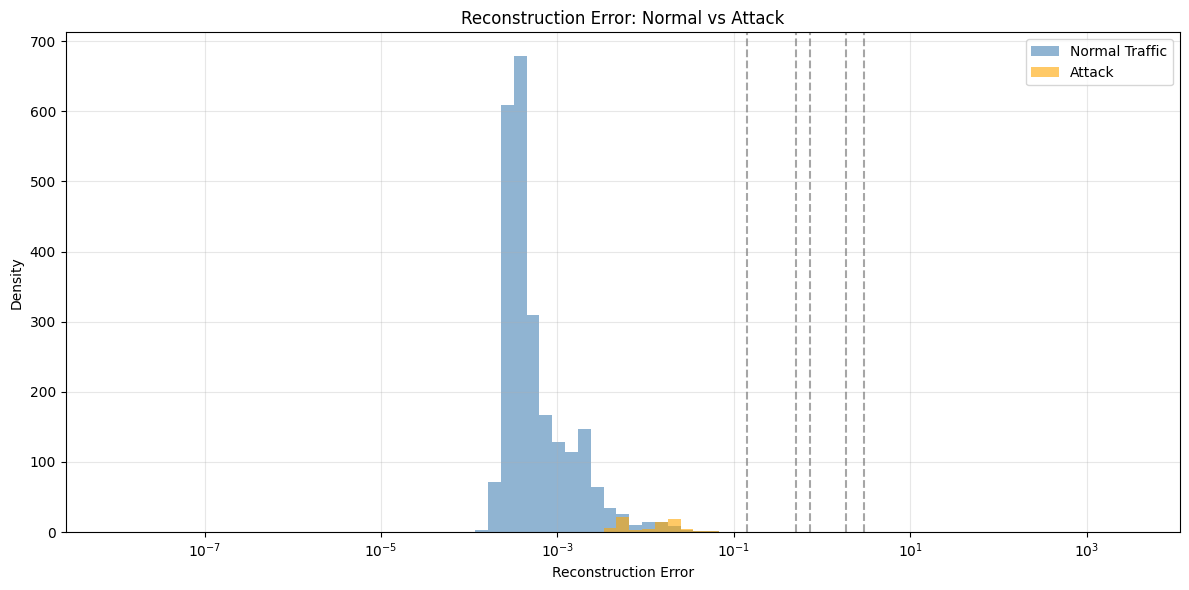

In [57]:
import numpy as np
import matplotlib.pyplot as plt

normal_errors = val_errors_full[~is_attack]
attack_errors = val_errors_full[is_attack]

# Tránh log(0)
eps = 1e-8
normal_errors = np.clip(normal_errors, eps, None)
attack_errors = np.clip(attack_errors, eps, None)

max_error = max(
    val_errors_full.max(),
    max(thresholds_full)
)

bins = np.logspace(
    np.log10(eps),
    np.log10(max_error),
    80
)

plt.figure(figsize=(12, 6))

plt.hist(
    normal_errors,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Normal Traffic",
    color="steelblue"
)

plt.hist(
    attack_errors,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Attack",
    color="orange"
)

for threshold in thresholds_full:
    if np.isclose(threshold, final_threshold):
        plt.axvline(
            threshold,
            color="red",
            linewidth=2.5,
            label=f"Final threshold = {threshold:.4f}"
        )
    else:
        plt.axvline(
            threshold,
            color="gray",
            linestyle="--",
            alpha=0.7
        )

plt.xscale("log")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error: Normal vs Attack")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"D:\Python project\PROJECT\models\validation_error_histogram.png",
    dpi=200
)

plt.show()